In [1]:
# Install libraries
!pip install pandas scikit-learn kagglehub joblib

In [2]:
# Loading libraries

# Data Preprocessing
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualization
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

# Save model
import joblib

In [3]:
# Importing the data - loan predictor dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nabihazahid/loan-prediction-dataset-2025")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\timio\.cache\kagglehub\datasets\nabihazahid\loan-prediction-dataset-2025\versions\2


In [4]:
# Reading the data
df = pd.read_csv(f"{path}//loan_dataset_20000.csv")

df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [5]:
# Unique values in the columns
df_columns = df.columns

for column in df_columns:
    print(f"{column.title()}: {df[column].unique()}")
# df_columns


Age: [59 72 49 35 63 28 41 39 43 31 44 73 56 60 23 42 22 64 50 58 53 32 45 69
 47 62 48 36 67 71 75 57 27 29 38 24 34 70 46 40 55 37 26 74 54 30 51 68
 65 61 21 25 33 52 66]
Gender: ['Male' 'Female' 'Other']
Marital_Status: ['Married' 'Single' 'Divorced' 'Widowed']
Education_Level: ["Master's" "Bachelor's" 'High School' 'Other' 'PhD']
Annual_Income: [24240.19 20172.98 26181.8  ... 18642.02 22181.39 23737.7 ]
Monthly_Income: [2020.02 1681.08 2181.82 ... 2671.91 1848.45 1978.14]
Employment_Status: ['Employed' 'Unemployed' 'Self-employed' 'Student' 'Retired']
Debt_To_Income_Ratio: [0.074 0.219 0.234 0.264 0.26  0.081 0.165 0.135 0.375 0.166 0.17  0.313
 0.272 0.153 0.269 0.059 0.092 0.21  0.229 0.113 0.158 0.1   0.067 0.14
 0.122 0.425 0.222 0.212 0.195 0.132 0.562 0.111 0.09  0.199 0.218 0.101
 0.088 0.117 0.154 0.163 0.04  0.104 0.241 0.206 0.143 0.069 0.107 0.183
 0.171 0.098 0.44  0.039 0.073 0.294 0.106 0.358 0.147 0.097 0.221 0.094
 0.319 0.052 0.291 0.033 0.057 0.075 0.354 0.085 0.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

This dataset has no missing values
interest_rate, installment and grade_subgrade are columns a bak=nk would only assign after a loan is approved

### Data Cleaning

In [7]:
# Converting text columns to numbers

# Deriving columns that have none integer/float columns (object)
object_columns = list()
# Loops through the dataframe columns
for column in df.columns:
    if df.dtypes[column] == object:
        object_columns.append(column) 


# displays object-type columns
print(df[object_columns])

       gender marital_status education_level employment_status  \
0        Male        Married        Master's          Employed   
1      Female        Married      Bachelor's          Employed   
2      Female         Single     High School          Employed   
3      Female         Single     High School          Employed   
4       Other         Single           Other          Employed   
...       ...            ...             ...               ...   
19995  Female        Married      Bachelor's          Employed   
19996  Female        Married      Bachelor's          Employed   
19997  Female         Single        Master's           Student   
19998    Male        Married        Master's           Retired   
19999  Female        Married           Other          Employed   

             loan_purpose grade_subgrade  
0                     Car             B5  
1      Debt consolidation             F1  
2                Business             B4  
3                   Other          

In [8]:
# Encoding the object type columns (converting text to number) - categorical to numeric

df_copy = df.copy()

# Label Encoder from Sklearn
label_encoder = LabelEncoder()
for column in object_columns:
    df_copy[column]= label_encoder.fit_transform(df[column])


# displays object-type columns
print(df[object_columns].head())
print(df_copy.head())

   gender marital_status education_level employment_status  \
0    Male        Married        Master's          Employed   
1  Female        Married      Bachelor's          Employed   
2  Female         Single     High School          Employed   
3  Female         Single     High School          Employed   
4   Other         Single           Other          Employed   

         loan_purpose grade_subgrade  
0                 Car             B5  
1  Debt consolidation             F1  
2            Business             B4  
3               Other             A5  
4                 Car             D5  
   age  gender  marital_status  education_level  annual_income  \
0   59       1               1                2       24240.19   
1   72       0               1                0       20172.98   
2   49       0               2                1       26181.80   
3   35       0               2                1       11873.84   
4   63       2               2                3       25326.44 

### Splitting the data

In [9]:
# Splitting the data into features (X) annd target (y)
X = df_copy.drop('loan_paid_back', axis=1)
y = df_copy['loan_paid_back']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Fitting and Evaulating the Random Forest Model

In [10]:
# Instance of Random Forest Model
rf = RandomForestClassifier()

# Fitting the model with training data
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# Model's prediction
y_pred = rf.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.90325


### Hyperparameter Tuning

- n_estimators: the number of deciosn trees in the forest
- max_depth: the maximum depth of each decision tree in the forest

In [12]:
# Parameter distributions
param_dist = {
    'n_estimators': randint(10, 100),
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

# Creating a random forest classifier
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10, # number of models
    cv=5, # cross-validation
    scoring='accuracy',
    n_jobs=-1, 
    random_state=42
)

In [13]:
# Fitting the rand_search
rand_search.fit(X_train, y_train)

# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print(f'Best hyperparameters: {rand_search.best_params_}')

Best hyperparameters: {'max_depth': 12, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 69}


### Evaluating the best model

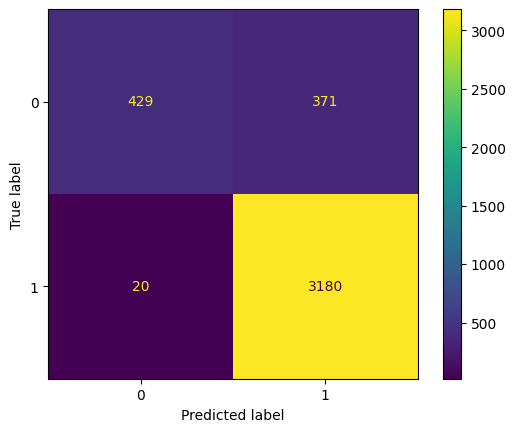

In [14]:
# Generate predictions with the best model
y_pred = best_rf.predict(X_test)

# Creating the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [15]:
# Evaluating the best model with accuracy, precision, and recall
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.90225
Precision: 0.8955223880597015
Recall: 0.99375


In [16]:
# Feature importance from the model 
# importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
# importances.sort_values(ascending= False).plot.bar()

In [17]:
# Saving model
print(best_rf)
model = best_rf

filename = 'randomforestclassifier.pkl'
joblib.dump(model, filename)

print(f"Model saved to {filename}")

RandomForestClassifier(max_depth=12, min_samples_leaf=4, min_samples_split=5,
                       n_estimators=69, n_jobs=-1, random_state=42)
Model saved to randomforestclassifier.pkl
